# Деревья решений

Деревья решений — это мощный инструмент машинного обучения, который принимает решения на основе логических предикатов (например, объект > x).

Эта модель лежит в основе многих современных алгоритмов и используется для решения задач классификации и регрессии.

Деревья решений работают, последовательно разбивая данные на узлы в зависимости от ответа на предикат. Разбиение продолжается до тех пор, пока не будет достигнут лист — конечный узел дерева.

В задаче классификации:
- В каждом узле выбирается такой признак и порог, чтобы максимально уменьшить неопределённость в получившихся группах.
- Неопределённость измеряется с помощью критерия Gini (по умолчанию) или энтропии.
- В листе предсказывается класс большинства объектов, попавших в этот лист.

Gini для узла вычисляется по формуле:
$$ 
Gini = 1 − \sum_{i=1}^{n} p_i^2
$$
где $p_i$ — доля объектов класса $i$ в узле.

Чем меньше Gini, тем "чище" группа (например, если все объекты одного класса, то $Gini = 0$)

Энтропия для узла с $K$ классами:

$$
H = -\sum_{k=1}^{K} p_k \log_2(p_k)
$$

где:
- $p_k$ — доля объектов класса $k$ в данном узле  
  (т.е. $p_k = \frac{\text{число объектов класса } k}{\text{общее число объектов в узле}}$)

Дерево обучается жадно: на каждом шаге выбирается лучшее разбиение из всех возможных. Это делает деревья простыми и интерпретируемыми, но склонными к переобучению. Если не ограничивать глубину, дерево может запомнить все обучающие примеры, включая шум.

**Сюда бы картинку, как энт помогает выбрать съедобный гриб**

## Задача 1

В этом задании тебе потребуется определить являются ли грибы ядовитыми или нет, используя `Decision Tree` из `sklearn`

1. **Подготовка данных:**
   - Загрузи датасет `mushrooms.csv`.
   - Выдели целевую переменную: `class` (ядовитый или съедобный гриб) и закодируй (ядовитый = 1, съедобный = 0)
   - Преобразуй категориальные признаки в числовые с помощью OneHotEncoding.

2. **Обучение модели:**
   - Раздели данные на обучающую и тестовую выборки (например, 80% на 20%).
   - Обучи модель `DecisionTreeClassifier` из `sklearn.tree` на обучающей выборке.
   - Выведи параметры дерева: глубину, количество листьев и критерий разбиения.

3. **Оценка качества:**
   - Вычисли точность (accuracy) на тестовой выборке.
   - Построй confusion matrix (матрицу ошибок) для тестовой выборки.

4. **Визуализация:**
   - Построй график дерева решений с помощью `plot_tree` из `sklearn.tree`.
   - Построй график важности признаков (`model.feature importance`).
   - Интерпретируй результаты: модель хорошо предсказывает данные?

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import datetime
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings('ignore')

In [3]:
mushroom = fetch_ucirepo(id=73) 

X = mushroom.data.features 
y = mushroom.data.targets 
y['poisonous'] = y['poisonous'].map({'p': 1, 'e': 0})

In [4]:
ohe = OneHotEncoder()
data_encoded = ohe.fit_transform(X).toarray()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(data_encoded, y, test_size=0.3, random_state=42)

In [6]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [42]:
print(f'Глубина: {clf.get_depth()}, Кол-во листьев: {clf.get_n_leaves()}')

Глубина: 7, Кол-во листьев: 14


In [8]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')

Accuracy: 1.0


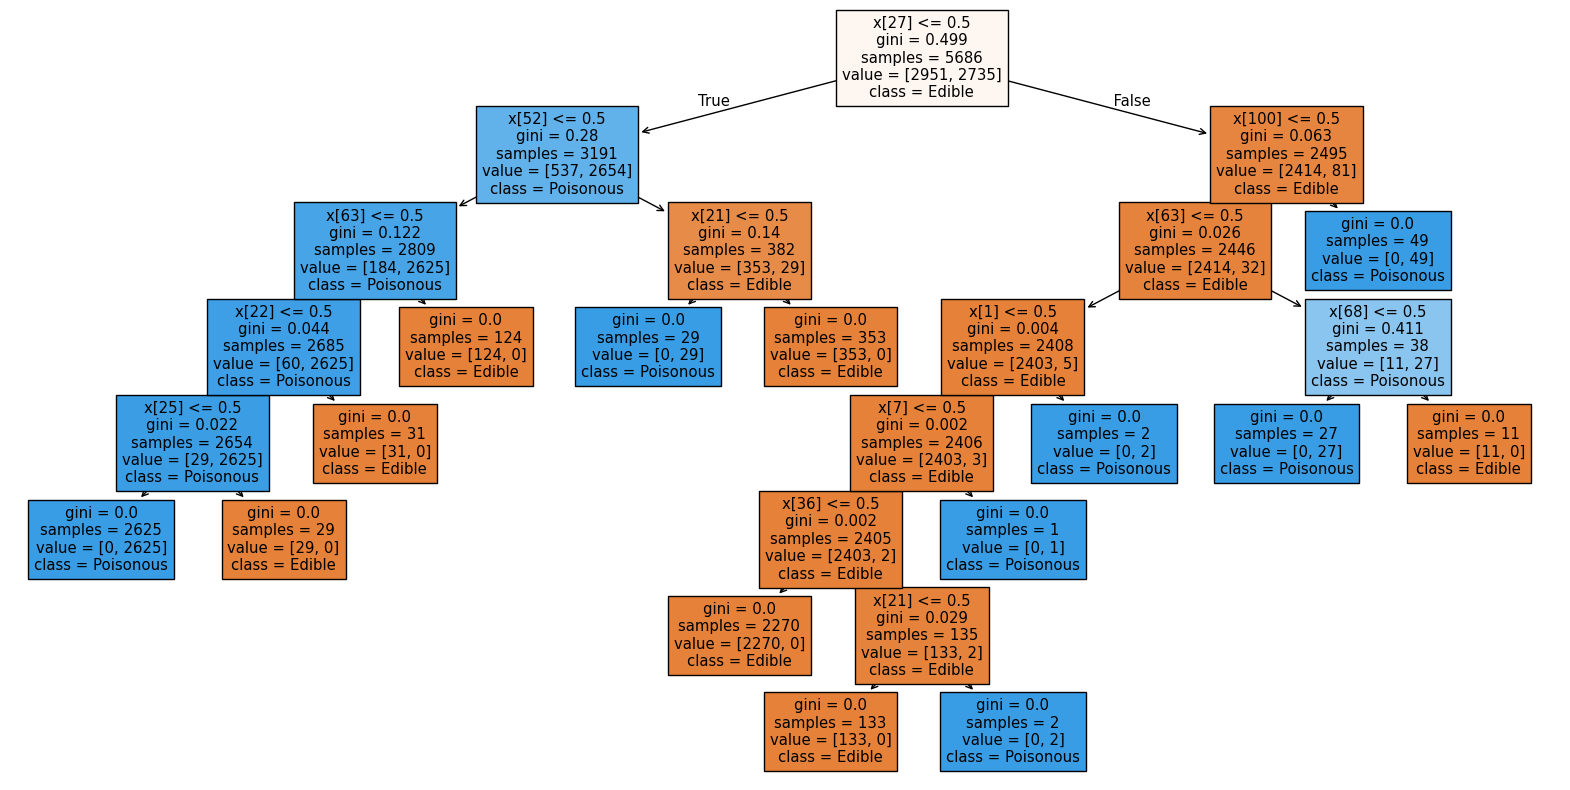

In [9]:
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, class_names=['Edible', 'Poisonous'])
plt.show()

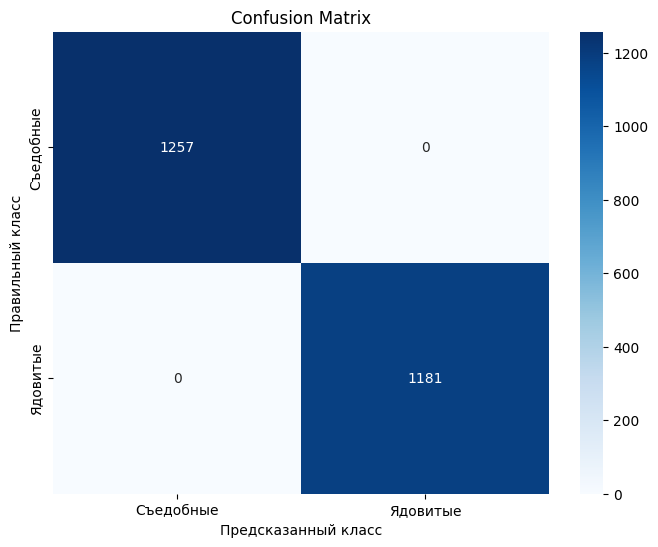

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Съедобные', 'Ядовитые'], yticklabels=['Съедобные', 'Ядовитые'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Правильный класс')
plt.title('Confusion Matrix')
plt.show()

                        Feature  Importance
27                       odor_n    0.630137
52                 stalk-root_c    0.174635
63   stalk-surface-below-ring_y    0.093039
100         spore-print-color_r    0.032963
22                       odor_a    0.021118
21                    bruises_t    0.020268
25                       odor_l    0.020207
68     stalk-color-above-ring_n    0.005506
1                   cap-shape_c    0.001404
7                 cap-surface_g    0.000703


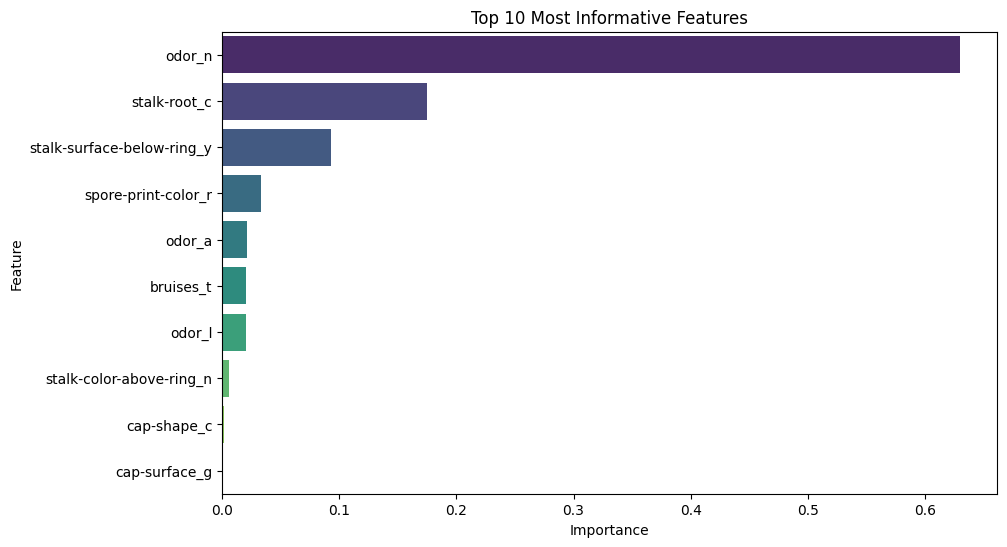

In [11]:
importances = clf.feature_importances_
feature_names = ohe.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Informative Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Задача 1.2.

Мы уже видели, что дерево без ограничений даёт почти идеальную точность (accuracy ≈ 1.0), но это часто признак переобучения.  
В этом задании мы искусственно ограничим глубину дерева и сравним, как ведут себя два разных критерия разбиения: Gini и Entropy.

1. **Обучение двух ограниченных деревьев**  
   - Обучи дерево с `criterion='gini'`, `max_depth=2` и `min_samples_leaf=5`  
   - Обучи второе дерево с `criterion='entropy'`, с теми же гиперпараметрами
   - Обучи оба дерева на той же обучающей выборке

2. **Оценка качества**  
   - Посчитай accuracy на обучающей и тестовой выборках для обоих деревьев  
   - Сравни разницу train/test с неограниченным деревом (из предыдущего задания)

3. **Матрицы ошибок**  
   - Построй две матрицы ошибок (confusion matrix):  
     - для дерева с Gini 
     - для дерева с Entropy 

4. **Расчёт метрик по матрицам**  
   - Для каждой матрицы посчитай:  
     - Accuracy  
     - Precision (для класса ядовитых — TP / (TP + FP))  
     - Recall (для класса ядовитых — TP / (TP + FN))  
     - F1-score (2 * Precision * Recall / (Precision + Recall))  
   - Сравни все четыре метрики между Gini и Entropy  
   - Определи, какой критерий выигрывает и по каким метрикам

5. **Визуализация деревьев**  
   - Построй `plot_tree` для обоих деревьев
   - Сравни визуально:  
     - отличаются ли первые разбиения?  
     - какое дерево выглядит проще/чище?

In [31]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)
clf_gini.fit(X_train, y_train)

clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)
clf_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [32]:
y_pred_gini = clf_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

y_pred_entropy = clf_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print(f'Accuracy Gini: {accuracy_gini}')
print(f'Accuracy Entropy: {accuracy_entropy}')

Accuracy Gini: 0.9479081214109926
Accuracy Entropy: 0.9220672682526662


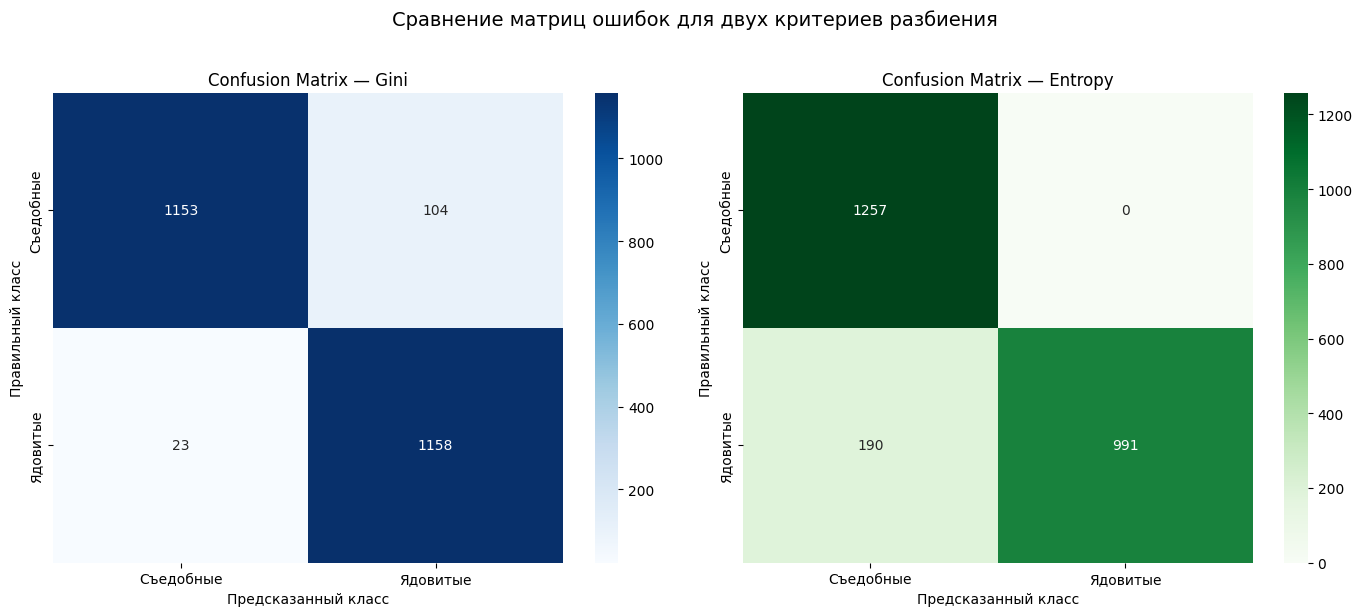

In [ ]:
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_gini, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Съедобные', 'Ядовитые'],
            yticklabels=['Съедобные', 'Ядовитые'],
            ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Правильный класс')
axes[0].set_title('Confusion Matrix — Gini')

sns.heatmap(cm_entropy, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=['Съедобные', 'Ядовитые'],
            yticklabels=['Съедобные', 'Ядовитые'],
            ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Правильный класс')
axes[1].set_title('Confusion Matrix — Entropy')

plt.suptitle('Сравнение матриц ошибок для двух критериев разбиения', 
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

In [37]:
def calc_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

acc_g, prec_g, rec_g, f1_g = calc_metrics(cm_gini)
acc_e, prec_e, rec_e, f1_e = calc_metrics(cm_entropy)

print("=== Метрики")
print(f"Gini:")
print(f"  Accuracy:  {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall:    {rec_g:.4f}")
print(f"  F1-score:  {f1_g:.4f}")

print(f"\nEntropy:")
print(f"  Accuracy:  {acc_e:.4f}")
print(f"  Precision: {prec_e:.4f}")
print(f"  Recall:    {rec_e:.4f}")
print(f"  F1-score:  {f1_e:.4f}")

=== Метрики
Gini:
  Accuracy:  0.9479
  Precision: 0.9176
  Recall:    0.9805
  F1-score:  0.9480

Entropy:
  Accuracy:  0.9221
  Precision: 1.0000
  Recall:    0.8391
  F1-score:  0.9125


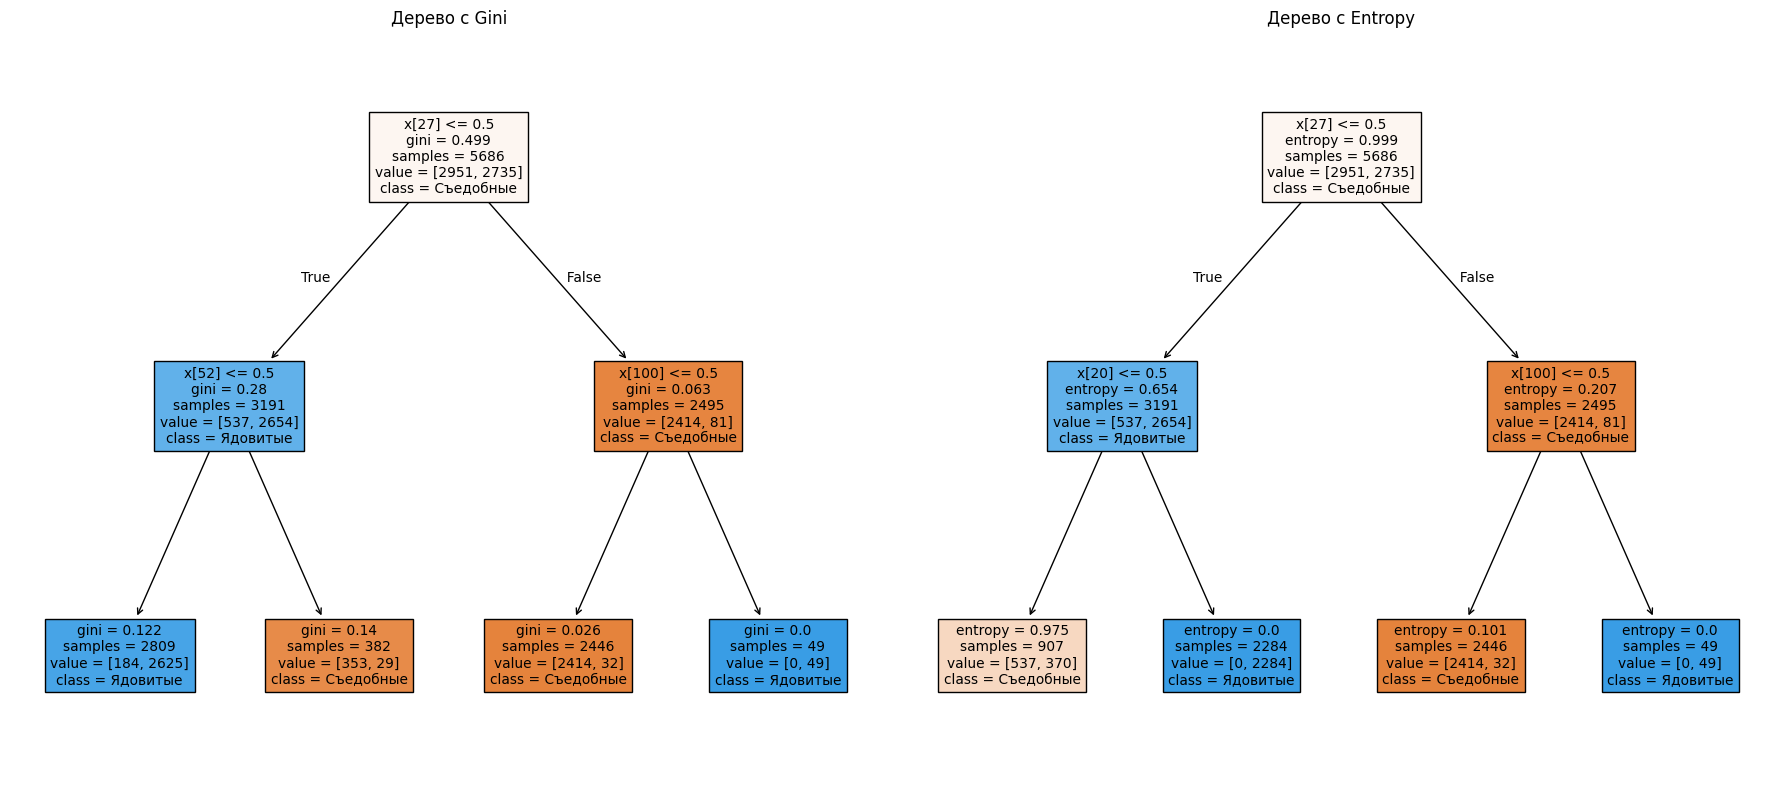

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_tree(clf_gini,
          class_names=['Съедобные', 'Ядовитые'],
          filled=True,
          ax=axes[0])
axes[0].set_title("Дерево с Gini")

plot_tree(clf_entropy,
          class_names=['Съедобные', 'Ядовитые'],
          filled=True,
          ax=axes[1])
axes[1].set_title("Дерево с Entropy")

plt.tight_layout()
plt.show()

## Задача 2

В этом задании будем обучать дерево для задачи **регрессии** и столкнемся с проблемой **переобучения**  
Для этого возьмём датасет **ViolentCrimesPerPop** и будем предсказывать уровень насильственной преступности на 100 тыс. населения (целевая переменная — `ViolentCrimesPerPop`).

1. **Загрузи и предобработай датасет**  
   - Загрузи данные в DataFrame  
   - Проверь наличие пропусков:  
     - посчитай количество пропусков по столбцам (`df.isna().sum()`)  
   - Обработай пропуски:  
     - для числовых признаков заполни медианой или средним (выбери подходящий способ)  
     - для категориальных (если есть) — модой или отдельной категорией "missing"  
   - Удали неинформативные признаки: `state`, `county`, `community`, `communityname`, `fold`
   - Проверь типы данных: убедись, что числовые признаки имеют тип float/int, категориальные — object/category  
   - Раздели данные на обучающую и тестовую выборки (`test_size=0.2, random_state=42`)

2. **Обучение модели дерева решений без ограничений**  
   - Обучи модель `DecisionTreeRegressor` из `sklearn.tree` **без ограничений** глубины и других регуляризаций  
   - Посчитай качество на обучающей и тестовой выборках:  
     - Mean Squared Error (MSE)  
     - Mean Absolute Error (MAE)  
     - R²-score  
   - Сохрани результаты

3. **Ручками выставь глубину и другие параметры**  
   - Попробуй 3–5 разных наборов гиперпараметров вручную:  
     - `max_depth`
     - `min_samples_split`
     - `min_samples_leaf`
   - Обучи модель и запиши MSE / MAE / R² на **тестовой** выборке  
   - Сравни с исходной моделью

4. **Перебери гиперпараметры при помощи GridSearchCV**  
   - Задай небольшую сетку параметров, например:  
     - `max_depth`: [3, 5, 7, 10, 15, None]  
     - `min_samples_split`: [2, 5, 10, 20, 50]  
     - `min_samples_leaf`: [1, 3, 5, 10, 20]  
   - Используй `GridSearchCV` (или `RandomizedSearchCV`) с кросс-валидацией `cv = 5` и метрикой `neg_mean_squared_error`  
   - Обучи поиск  
   - Выведи лучшие параметры и качество на тестовой выборке для модели с найденными параметрами  
   - Сравни результат с лучшей ручной настройкой и с неограниченным деревом

5. **Финальная визуализация и анализ переобучения**  
   - Отрисуй дерево без ограничений (из пункта 2) с помощью `plot_tree` — для наглядности ограничь отображение глубиной 4–5 уровней (`max_depth=4` в `plot_tree`)  
   - Отрисуй дерево с лучшими параметрами из GridSearchCV (или из ручной настройки) с той же ограниченной глубиной отображения  
   - Сравни два дерева визуально:  
     - насколько глубже и сложнее дерево без ограничений?  
     - как отличаются первые разбиения?  

In [43]:
communities_and_crime = fetch_ucirepo(id=183)
X = communities_and_crime.data.features
y = communities_and_crime.data.targets
X.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?


In [44]:
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce')

In [45]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

In [46]:
cols_to_drop = X.columns[X.isna().mean() >= 0.8]

X = X.drop(columns=cols_to_drop)

remaining_na = X.isna().sum().sum()
print('Общее число пропущенных значений после импутации:', remaining_na)

Общее число пропущенных значений после импутации: 0


In [47]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 122 entries, population to PolicBudgPerPop
dtypes: float64(122)
memory usage: 1.9 MB


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
tree_unlimited = DecisionTreeRegressor(random_state=42)
tree_unlimited.fit(X_train, y_train)

# Предсказания
y_pred_train_un = tree_unlimited.predict(X_train)
y_pred_test_un  = tree_unlimited.predict(X_test)

# Метрики
mse_train_un = mean_squared_error(y_train, y_pred_train_un)
mae_train_un = mean_absolute_error(y_train, y_pred_train_un)
r2_train_un  = r2_score(y_train, y_pred_train_un)

mse_test_un = mean_squared_error(y_test, y_pred_test_un)
mae_test_un = mean_absolute_error(y_test, y_pred_test_un)
r2_test_un  = r2_score(y_test, y_pred_test_un)

print("Дерево без ограничений:")
print(f"Train → MSE: {mse_train_un:.4f}, MAE: {mae_train_un:.4f}, R²: {r2_train_un:.4f}")
print(f"Test  → MSE: {mse_test_un:.4f}, MAE: {mae_test_un:.4f}, R²: {r2_test_un:.4f}")

Дерево без ограничений:
Train → MSE: 0.0000, MAE: 0.0000, R²: 1.0000
Test  → MSE: 0.0352, MAE: 0.1224, R²: 0.2654


In [50]:
hand_tree = DecisionTreeRegressor(
                max_depth=7,
                min_samples_split=10,
                min_samples_leaf=10,
                random_state=42
            )
hand_tree.fit(X_train, y_train)
y_pred_test = hand_tree.predict(X_test)

hand_mse = mean_squared_error(y_test, y_pred_test)
hand_mae = mean_absolute_error(y_test, y_pred_test)
hand_r2  = r2_score(y_test, y_pred_test)
print("Дерево с ручными гиперпараметрами:")
print(f"Test → MSE: {hand_mse:.4f}, MAE: {hand_mae:.4f}, R²: {hand_r2:.4f}")

Дерево с ручными гиперпараметрами:
Test → MSE: 0.0258, MAE: 0.1042, R²: 0.4611


In [51]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
best_tree = grid_search.best_estimator_

y_pred_test_best = best_tree.predict(X_test)
mse_best = mean_squared_error(y_test, y_pred_test_best)
mae_best = mean_absolute_error(y_test, y_pred_test_best)
r2_best  = r2_score(y_test, y_pred_test_best)

print(f"Лучшее дерево (GridSearch) → Test: MSE={mse_best:.4f}, MAE={mae_best:.4f}, R²={r2_best:.4f}")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Лучшее дерево (GridSearch) → Test: MSE=0.0218, MAE=0.0990, R²=0.5456


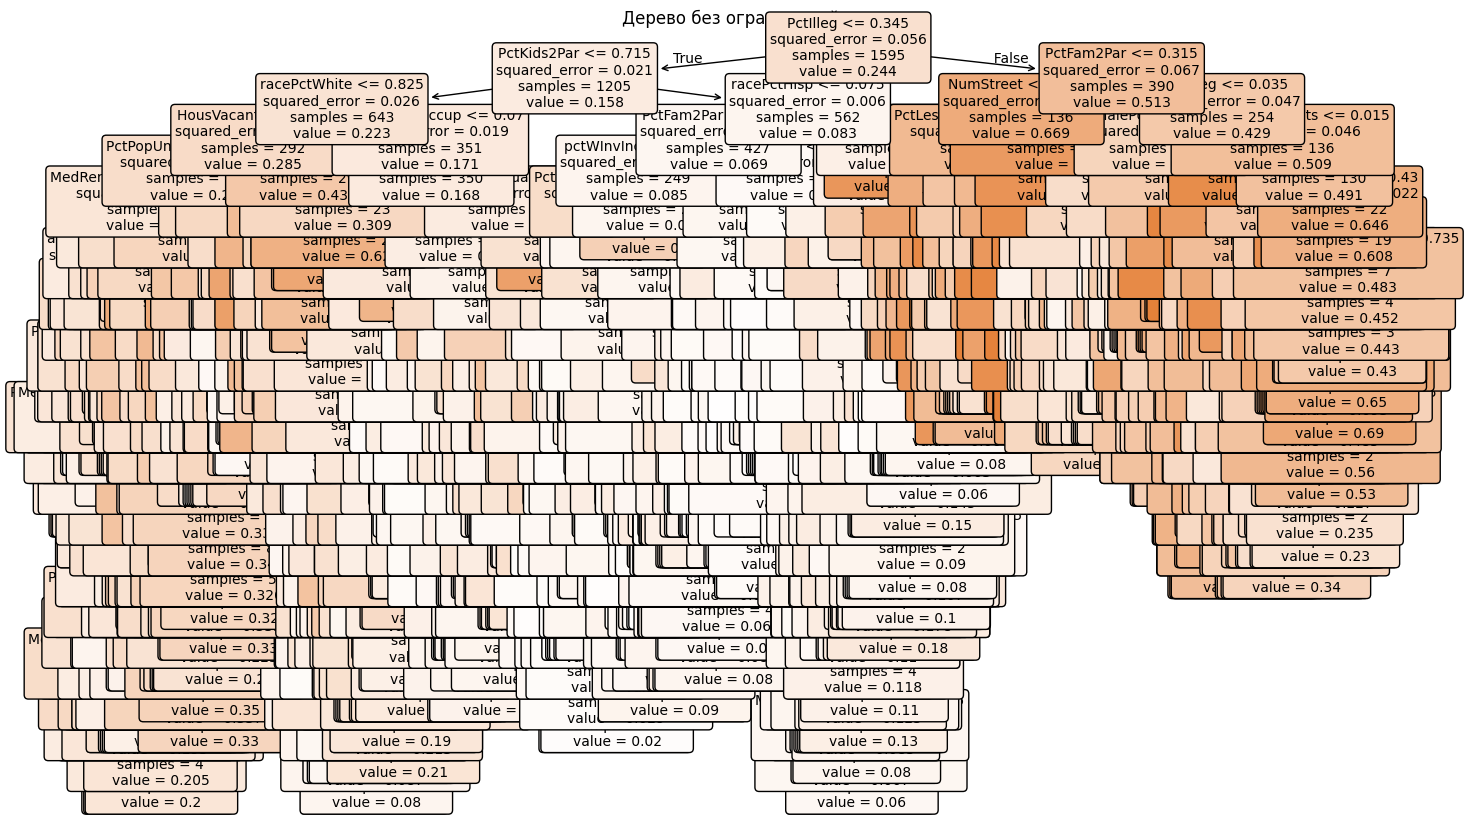

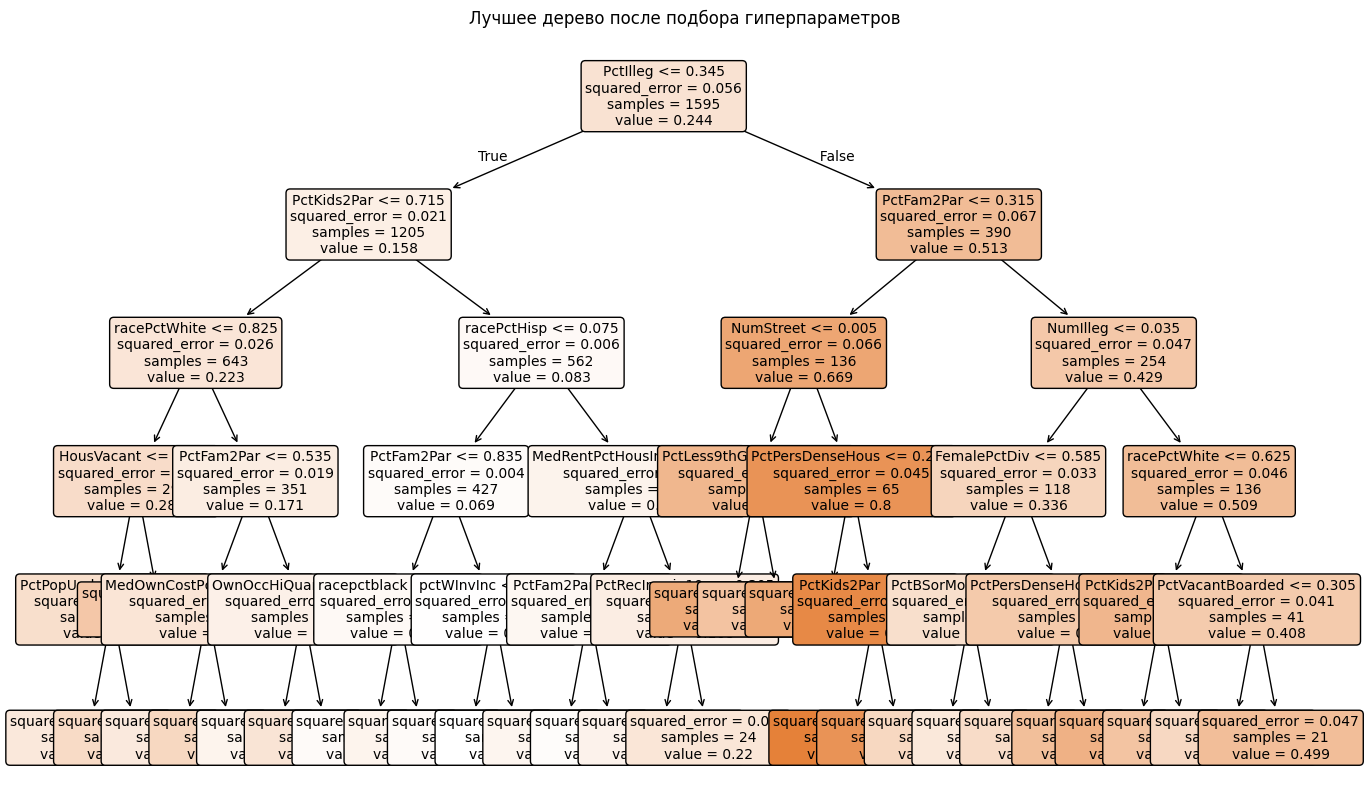

In [52]:
plt.figure(figsize=(16, 10))
plot_tree(
    tree_unlimited,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Дерево без ограничений ")
plt.show()

plt.figure(figsize=(16, 10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Лучшее дерево после подбора гиперпараметров")
plt.show()

## Задача 3

В этом задании мы покажем **неустойчивость дерева решений** — один из главных недостатков одиночных деревьев.  
Даже небольшие изменения в обучающей выборке (удаление нескольких объектов, перемешивание строк) могут привести к совершенно другой структуре дерева: другой корень, другие разбиения, другая важность признаков и иногда заметно хуже качество на тесте.

Чтобы это увидеть на практике, мы будем использовать **одну и ту же тестовую выборку**, но немного менять обучающую — и смотреть, как меняется качество и структура дерева.

1. **Базовое дерево**  
   - Обучи `DecisionTreeRegressor` **без ограничений** на полном `X_train`, `y_train` (как в Задаче 2)  
   - Посчитай MSE, MAE, R² на **тестовой** выборке (оставь test неизменным!)  
   - Сохрани модель как `tree_base`  
   - Выведи характеристики дерева:  
     - максимальная глубина (`tree_base.get_depth()`)  
     - количество листьев (`tree_base.get_n_leaves()`)  
     - общее количество узлов (`tree_base.tree_.node_count`)  
   - Запиши значения метрик и характеристик

2. **Эксперимент 1: Удаляем небольшую часть объектов из train**  
   - Случайно удали 5–10% объектов из `X_train`, `y_train` (например, оставь 90% строк)  
   - Обучи новое дерево `tree_del` на уменьшенной выборке  
   - Посчитай те же метрики **на той же тестовой выборке**  
   - Выведи характеристики дерева: глубину, количество листьев, количество узлов  
   - Сравни с базовым деревом: изменилось ли качество? Изменились ли характеристики?

3. **Эксперимент 2: Добавляем небольшой гауссов шум к признакам в train**  
   - Добавь к каждому значению в `X_train` гауссов шум с нулевым средним и небольшим стандартным отклонением (например, 0.05–0.1)  
   - Обучи новое дерево `tree_noise` на зашумлённых данных  
   - Посчитай метрики на том же тесте  
   - Выведи характеристики дерева: глубину, количество листьев, количество узлов  
   - Сравни с базовым деревом: изменилось ли качество? Изменились ли характеристики?

In [53]:
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(X_train, y_train)

y_pred_test_base = tree_base.predict(X_test)
mse_base = mean_squared_error(y_test, y_pred_test_base)
mae_base = mean_absolute_error(y_test, y_pred_test_base)
r2_base  = r2_score(y_test, y_pred_test_base)
print("Базовое дерево (без ограничений):")
print(f"  Test → MSE: {mse_base:.4f} | MAE: {mae_base:.4f} | R²: {r2_base:.4f}")
print(f"  Глубина: {tree_base.get_depth()}")
print(f"  Кол-во листьев: {tree_base.get_n_leaves()}")
print(f"  Кол-во узлов: {tree_base.tree_.node_count}")

Базовое дерево (без ограничений):
  Test → MSE: 0.0352 | MAE: 0.1224 | R²: 0.2654
  Глубина: 24
  Кол-во листьев: 1214
  Кол-во узлов: 2427


In [54]:
frac = 0.9  # оставляем 90%
n_keep = int(len(X_train) * frac)
idx_keep = np.random.choice(len(X_train), size=n_keep, replace=False)

X_train_del = X_train.iloc[idx_keep].copy()
y_train_del = y_train.iloc[idx_keep].copy()

tree_del = DecisionTreeRegressor(random_state=42)
tree_del.fit(X_train_del, y_train_del)

y_pred_del = tree_del.predict(X_test)
mse_del = mean_squared_error(y_test, y_pred_del)
mae_del = mean_absolute_error(y_test, y_pred_del)
r2_del  = r2_score(y_test, y_pred_del)

print(f"\nПосле удаления {100 - frac*100:.0f}% объектов:")
print(f"  Test → MSE: {mse_del:.4f} | MAE: {mae_del:.4f} | R²: {r2_del:.4f}")
print(f"  Глубина: {tree_del.get_depth()}")
print(f"  Кол-во листьев: {tree_del.get_n_leaves()}")
print(f"  Кол-во узлов: {tree_del.tree_.node_count}")


После удаления 10% объектов:
  Test → MSE: 0.0364 | MAE: 0.1269 | R²: 0.2403
  Глубина: 26
  Кол-во листьев: 1095
  Кол-во узлов: 2189


In [55]:
noise_level = 0.05
X_train_noise = X_train + np.random.normal(0, noise_level, X_train.shape)

tree_noise = DecisionTreeRegressor(random_state=42)
tree_noise.fit(X_train_noise, y_train)

y_pred_noise = tree_noise.predict(X_test)
mse_noise = mean_squared_error(y_test, y_pred_noise)
mae_noise = mean_absolute_error(y_test, y_pred_noise)
r2_noise  = r2_score(y_test, y_pred_noise)

print(f"\nПосле добавления гауссова шума (std={noise_level}):")
print(f"  Test → MSE: {mse_noise:.4f} | MAE: {mae_noise:.4f} | R²: {r2_noise:.4f}")
print(f"  Глубина: {tree_noise.get_depth()}")
print(f"  Кол-во листьев: {tree_noise.get_n_leaves()}")
print(f"  Кол-во узлов: {tree_noise.tree_.node_count}")


После добавления гауссова шума (std=0.05):
  Test → MSE: 0.0335 | MAE: 0.1181 | R²: 0.3004
  Глубина: 25
  Кол-во листьев: 1182
  Кол-во узлов: 2363


## Ансамбли алгоритмов

Мы только что увидели, насколько сильно может измениться дерево решений даже при минимальных изменениях в обучающих данных:
- удаление всего 10% объектов
- добавление небольшого шума

Меняется:
- структура дерева (глубина, первые разбиения, количество листьев и узлов)
- качество на тестовой выборке

Это происходит потому, что алгоритм построения дерева **жадный** и **детерминированный**

В результате одиночное дерево:
- очень чувствительно к шуму и выбросам
- склонно к переобучению (запоминает обучающие данные, включая шум)
- даёт нестабильные предсказания при небольших изменениях выборки

### Как бороться с этой неустойчивостью?

**Ансамбли** — это подход, когда мы обучаем **много** слабых моделей и комбинируем их предсказания.  
Идея простая: если каждая модель ошибается по-своему, то их усреднение (или голосование) даёт гораздо более стабильный и точный результат.

### Основные виды ансамблей

1. **Bagging (Bootstrap Aggregating)**  
   - Обучаем много моделей на **разных** подвыборках данных  
   - Каждая подвыборка — бутстреп (выборка с возвращением того же размера)  
   - Для регрессии: усредняем предсказания всех моделей  
   - Для классификации: голосуем большинством  
   → сильно снижает **дисперсию** (разброс), почти не увеличивая смещение

2. **Random Forest** — это улучшенный Bagging  
   - К бутстрепу добавляется ещё один слой случайности:  
     при каждом разбиении узла берётся **случайное подмножество признаков**
   - Деревья становятся менее похожими друг на друга → их ошибки лучше компенсируют друг друга  
   Преимущества Random Forest:  
   - почти не переобучается  
   - очень высокое качество «из коробки»  
   - встроенная оценка важности признаков  

3. **Бустинг** (XGBoost, CatBoost, LightGBM)  
   - Модели обучаются **последовательно**  
   - Каждая следующая модель исправляет ошибки предыдущих  
   → снижает и смещение, и дисперсию
   - Являются передовыми в решении табличных задач

### Почему ансамбли работают лучше одиночного дерева?

- **Разнообразие моделей** → ошибки разных деревьев компенсируют друг друга  
- **Усреднение / голосование** → снижает влияние шума и выбросов  
- **Снижение дисперсии** без сильного роста смещения  


## Фишки RandomForest

### OOB-score (Out-of-Bag score)

**OOB-score** — это внутренняя оценка качества модели Random Forest, которую можно получить **бесплатно**, без отдельной валидационной выборки.

**Как считается:**

- Каждое дерево обучается на своей бутстреп-выборке (примерно 63% объектов из train, остальные ~37% не попадают в неё — это и есть out-of-bag объекты)
- Для каждого объекта из train считается предсказание **только теми деревьями**, которые его **не** видели при обучении
- Затем все такие предсказания усредняются (или голосуются) - получаем предсказание для объекта

**Преимущества:**
- Не требует отдельного hold-out или кросс-валидации
- Обычно очень близок к качеству на тестовой выборке (особенно при большом числе деревьев)
- Стабилен и почти не зависит от random_state

### feature_importances_ (встроенная важность)

**Что это:** встроенная оценка важности признаков в деревьях и лесах.

**Как считается:** сумма уменьшения критерия (Gini/MSE) по всем разбиениям, где признак использовался (усреднённая по деревьям).

**Плюсы:** мгновенно доступна, легко визуализировать.

**Минусы:**  
- завышает важность коррелированных/«дешёвых» признаков  
- считается только на train - не отражает реальное влияние на новых данных

## Задача 4

Random Forest решает проблему неусточивойсти решения за счёт обучения **множества деревьев** на разных подвыборках данных (бутстреп) и случайного выбора признаков при каждом разбиении. В результате усреднение предсказаний многих деревьев даёт гораздо более стабильный и точный результат.

1. **Обучение базового Random Forest без подбора гиперпараметров**  
   - Обучи модель `RandomForestRegressor` из `sklearn.ensemble` на тех же `X_train`, `y_train`  
   - Включи `oob_score=True` (out-of-bag оценка качества)  
   - Посчитай метрики на тестовой выборке: MSE, MAE, R²  
   - Выведи также oob_score_  
   - Запиши результаты

2. **Подбор гиперпараметров для Random Forest**  
   - Задай сетку гиперпараметров (не слишком большую, чтобы поиск не занял много времени):   
   - Используй `GridSearchCV` (или `RandomizedSearchCV`) с cv=3–5 и метрикой `neg_mean_squared_error`  
   - Обучи поиск  
   - Выведи лучшие параметры и качество на тестовой выборке для модели с найденными параметрами  
   - Сравни с базовым Random Forest (без подбора)

3. **OOB-score и его интерпретация**  
   - Для лучшей модели из пункта 2 (или базовой) включи `oob_score=True`  
   - Сравни значение `oob_score_` с качеством на тестовой выборке (RMSE / MAE / R²)  
   - Повтори обучение 2–3 раза с разными `random_state` и сравни стабильность OOB-score и test-метрик  

4. **Сравнение важности признаков**  
   - Построй график важности признаков для лучшего Random Forest (`feature_importances_`, топ-10 признаков)  
   - Посчитай **Permutation Importance** на тестовой выборке (используй `sklearn.inspection.permutation_importance`)  
   - Сравни два списка топ-10 признаков: встроенная важность RF и permutation importance  
   - Построй два графика barplot рядом для наглядности  

5. **Cравнение с лучшей моделью с одним деревом**  
   - Сравни важность признаков с той, что была у лучшего одиночного дерева из Задачи 2  
   - Сделай выводы о преимуществах Random Forest над одиночным деревом в этой задаче

In [56]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [57]:
rf_base = RandomForestRegressor(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
mse_base_rf = mean_squared_error(y_test, y_pred_base)
mae_base_rf = mean_absolute_error(y_test, y_pred_base)
r2_base_rf  = r2_score(y_test, y_pred_base)

print(f"Test → MSE: {mse_base_rf:.4f} | MAE: {mae_base_rf:.4f} | R²: {r2_base_rf:.4f}")
print(f"OOB score: {rf_base.oob_score_:.4f}")

Test → MSE: 0.0183 | MAE: 0.0927 | R²: 0.6173
OOB score: 0.6571


In [66]:
param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [15, 20],
    'max_features': ['sqrt', 0.3],
    'min_samples_leaf': [1, 3, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True),
    param_grid_rf,
    cv=4,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_

print("\nЛучшие параметры:", grid_rf.best_params_)

y_pred_best_rf = rf_best.predict(X_test)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
r2_best_rf  = r2_score(y_test, y_pred_best_rf)
print(f"Лучший RF → Test: MSE={mse_best_rf:.4f} | MAE={mae_best_rf:.4f} | R²={r2_best_rf:.4f}")

Fitting 4 folds for each of 24 candidates, totalling 96 fits

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
Лучший RF → Test: MSE=0.0178 | MAE=0.0916 | R²=0.6276


In [60]:
oob_scores = []
for rs in range(1, 100, 10):
    rf_temp = RandomForestRegressor(
        **grid_rf.best_params_,
        oob_score=True,
        random_state=rs,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)

print("OOB-score при разных random_state:", [f"{x:.4f}" for x in oob_scores])
print(f"Средний OOB-score: {np.mean(oob_scores):.4f}")
print(f"Сравнение с test R² лучшего RF: {r2_best_rf:.4f}")

OOB-score при разных random_state: ['0.6727', '0.6698', '0.6691', '0.6666', '0.6703', '0.6693', '0.6720', '0.6708', '0.6700', '0.6708']
Средний OOB-score: 0.6701
Сравнение с test R² лучшего RF: 0.6276


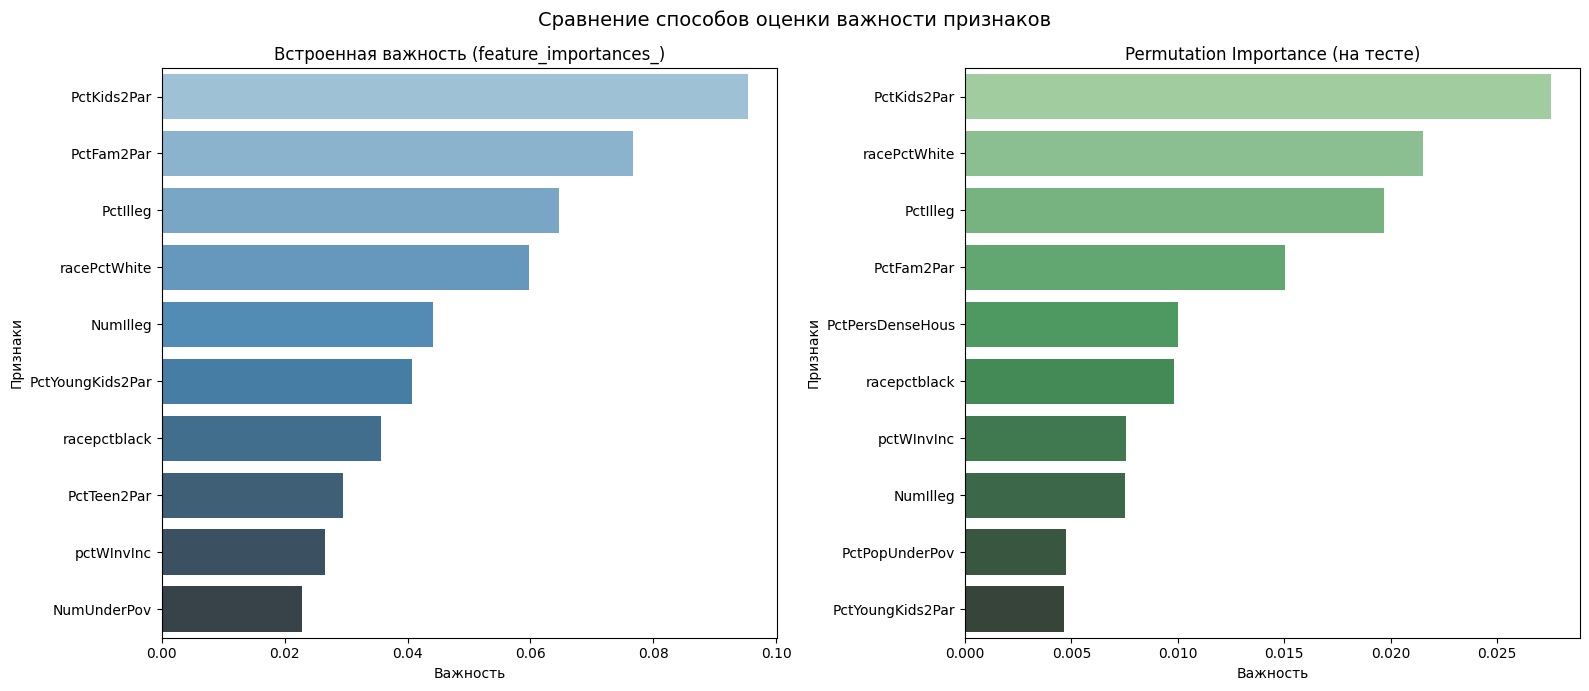

Топ-5 по встроенной важности: ['PctKids2Par', 'PctFam2Par', 'PctIlleg', 'racePctWhite', 'NumIlleg']
Топ-5 по Permutation Importance: ['PctKids2Par', 'racePctWhite', 'PctIlleg', 'PctFam2Par', 'PctPersDenseHous']


In [63]:
importances_rf = pd.Series(rf_best.feature_importances_, index=X.columns)\
                    .sort_values(ascending=False)[:10]

perm_importance = permutation_importance(rf_best, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_sorted_idx = perm_importance.importances_mean.argsort()[-10:]
perm_importances = pd.Series(perm_importance.importances_mean[perm_sorted_idx], 
                             index=X.columns[perm_sorted_idx])\
                    .sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=importances_rf.values, y=importances_rf.index, ax=axes[0], palette='Blues_d')
axes[0].set_title("Встроенная важность (feature_importances_)")
axes[0].set_ylabel("Признаки")
axes[0].set_xlabel("Важность")

sns.barplot(x=perm_importances.values, y=perm_importances.index, ax=axes[1], palette='Greens_d')
axes[1].set_title("Permutation Importance (на тесте)")
axes[1].set_ylabel("Признаки")
axes[1].set_xlabel("Важность")

plt.suptitle("Сравнение способов оценки важности признаков", fontsize=14)
plt.tight_layout()
plt.show()

print("Топ-5 по встроенной важности:", list(importances_rf.index[:5]))
print("Топ-5 по Permutation Importance:", list(perm_importances.index[:5]))

In [67]:
comparison = pd.DataFrame({
    'Модель': [
        'Лучшее одиночное дерево',
        'Базовый Random Forest',
        'Лучший Random Forest'
    ],
    'MSE_test': [mse_best, mse_base_rf, mse_best_rf],
    'MAE_test': [mae_best, mae_base_rf, mae_best_rf],
    'R²_test':  [r2_best,  r2_base_rf,  r2_best_rf],
    'OOB_score': [np.nan, rf_base.oob_score_, rf_best.oob_score_]
}).round(4)

print("\n=== Сводная таблица сравнения ===")
print(comparison.sort_values('MSE_test'))


=== Сводная таблица сравнения ===
                    Модель  MSE_test  MAE_test  R²_test  OOB_score
2     Лучший Random Forest    0.0178    0.0916   0.6276     0.6696
1    Базовый Random Forest    0.0183    0.0927   0.6173     0.6571
0  Лучшее одиночное дерево    0.0218    0.0990   0.5456        NaN


## Задача 5

В этой задаче решите задачу **прогнозирования ежедневных продаж** магазинов Rossmann с помощью **CatBoost**.

1. **Загрузи и объедини данные**  
   - Загрузи `train.csv` и `store.csv`  
   - Объедини их по полю `Store`

2. **Подготовь признаки**  
   - Преобразуй `Date` в datetime  
   - Добавь временные признаки (год, месяц, день, день недели, неделя года и т.д.)  
   - Обработай пропуски  
   - Отфильтруй строки с `Open == 0`  
   - Примени `log1p` к `Sales` → `Sales_log`

3. **Раздели данные по времени**  
   - Отсортируй по дате  
   - Последние 6 недель — тестовая выборка  
   - Остальное — обучающая

4. **Обучи CatBoostRegressor**  
   - Укажи категориальные признаки через `cat_features`  
   - Подбери разумные параметры (iterations, learning_rate, depth и др.)  
   - Используй `eval_set` и early stopping  
   - Посчитай RMSE и MAE на expm1(pred) и expm1(true)

5. **Визуализация и выводы**  
   - Построй топ-15 важных признаков  
   - Построй `scatter plot` с истинными предсказаниями и предсказаниями модели

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.4168521	test: 0.4012566	best: 0.4012566 (0)	total: 322ms	remaining: 5m 22s
100:	learn: 0.1889149	test: 0.1723263	best: 0.1723263 (100)	total: 20.6s	remaining: 3m 3s
200:	learn: 0.1735040	test: 0.1596285	best: 0.1596166 (199)	total: 43.9s	remaining: 2m 54s
300:	learn: 0.1651251	test: 0.1519880	best: 0.1519880 (300)	total: 1m 7s	remaining: 2m 37s
400:	learn: 0.1595275	test: 0.1468732	best: 0.1468732 (400)	total: 1m 34s	remaining: 2m 21s
500:	learn: 0.1558591	test: 0.1434170	best: 0.1434170 (500)	total: 2m 3s	remaining: 2m 3s
600:	learn: 0.1526447	test: 0.1407712	best: 0.1407712 (600)	total: 2m 29s	remaining: 1m 39s
700:	learn: 0.1496323	test: 0.1381385	best: 0.1381385 (700)	total: 3m 2s	remaining: 1m 17s
800:	learn: 0.1471475	test: 0.1362517	best: 0.1362517 (800)	total: 3m 32s	remaining: 52.9s
900:	learn: 0.1452689	test: 0.1342458	best: 0.1342458 (900)	total: 3m 58s	remaining: 26.2s
999:	learn: 0.1437117	test: 0.1328048	best: 0.1328048 (999)	total: 4m 23s	remaining: 0us

best

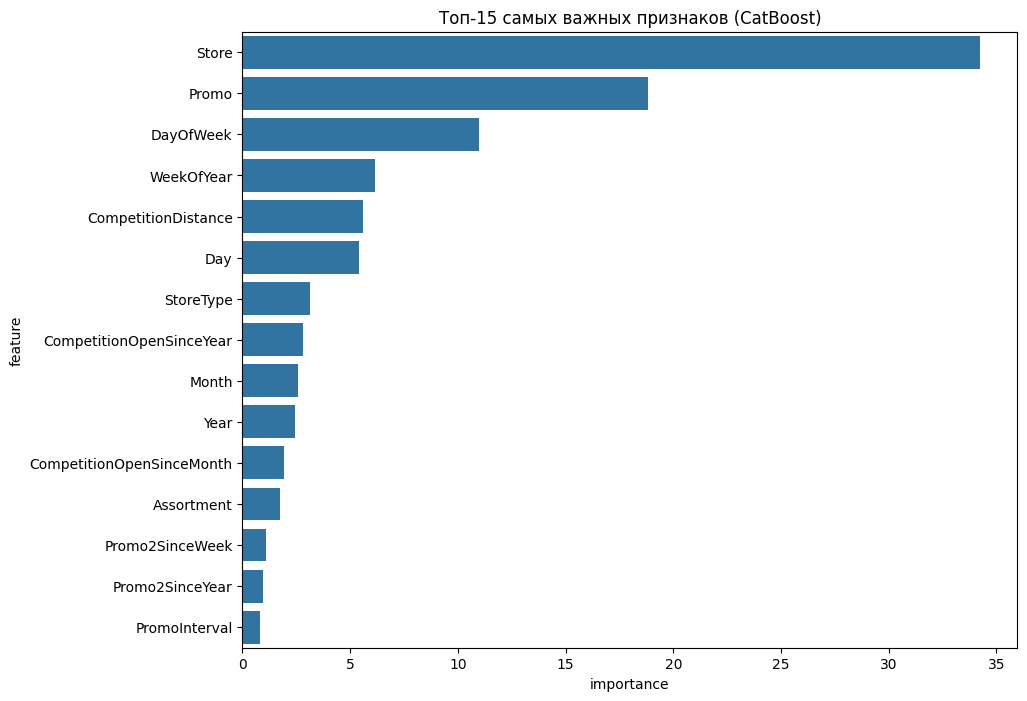

In [28]:
train = pd.read_csv('../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/train.csv', parse_dates=['Date'])
store = pd.read_csv('../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/store.csv')

df = train.merge(store, on='Store', how='left')

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1

categorical_features = [
    'Store', 'DayOfWeek', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'PromoInterval'
]

df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
df['CompetitionOpenSinceMonth'].fillna(1, inplace=True)
df['CompetitionOpenSinceYear'].fillna(df['Year'].median(), inplace=True)
df['Promo2SinceWeek'].fillna(0, inplace=True)
df['Promo2SinceYear'].fillna(0, inplace=True)
df['PromoInterval'].fillna('None', inplace=True)

df['Sales_log'] = np.log1p(df['Sales']) 

df = df[df['Open'] == 1].copy()

df.sort_values('Date', inplace=True)
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=6)
train_df = df[df['Date'] <= cutoff_date]
test_df  = df[df['Date'] > cutoff_date]

features = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'Year', 'Month', 'Day', 'WeekOfYear'
]

X_train = train_df[features]
y_train = train_df['Sales_log']

X_test = test_df[features]
y_test = test_df['Sales_log']

# Категориальные признаки (CatBoost сам их обработает)
cat_features_idx = [features.index(col) for col in categorical_features if col in features]

# 4. Обучение CatBoost
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    cat_features=cat_features_idx,
    early_stopping_rounds=100
)

for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('missing').astype(str)
        X_test[col]  = X_test[col].fillna('missing').astype(str)

train_pool = Pool(X_train, y_train, cat_features=cat_features_idx)
test_pool  = Pool(X_test, y_test, cat_features=cat_features_idx)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    plot=True
)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log) 
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Топ-15 самых важных признаков (CatBoost)')
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


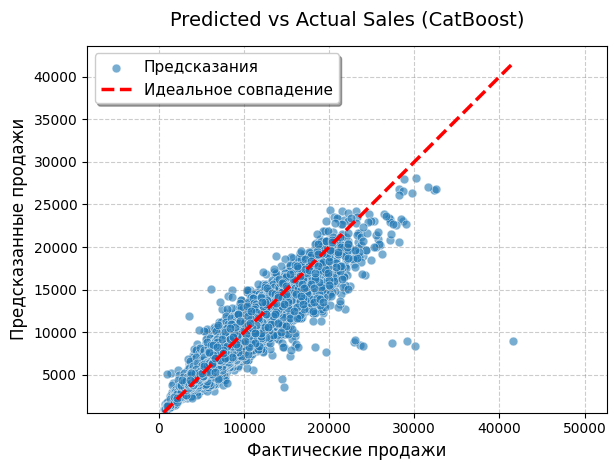

In [29]:
plt.scatter(y_true, y_pred, 
            alpha=0.6, 
            s=40,
            color='#1f77b4', 
            edgecolor='white', 
            linewidth=0.5,
            label='Предсказания')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', lw=2.5, 
         label='Идеальное совпадение')

plt.xlabel('Фактические продажи', fontsize=12)
plt.ylabel('Предсказанные продажи', fontsize=12)
plt.title('Predicted vs Actual Sales (CatBoost)', fontsize=14, pad=15)

plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)

plt.axis('equal')

plt.xlim(min_val * 0.95, max_val * 1.05)
plt.ylim(min_val * 0.95, max_val * 1.05)

plt.tight_layout()
plt.show()